# Table of Contents
* [Context](#context)
* [Dataset exploratory analysis](#exploration)
    * [Obtain the dataset](#obtain)
    * [Dataset structure](#structure)
    * [Dataset images in detail](#images)
* [Implementation](#implementation)
    * [Project structure](#structure)
    * [Implementation details](#details)
    * [Experiments](#experiments)
        * [Preprocessing](#preprocessing)
        * [Execution](#execution)
* [Results](#result)

## Context <a class="anchor" id="context"></a>
This notebook implements the experiments proposed on [my Msc. thesis](https://github.com/EstherRH00/TDA_Visual_Transformer/blob/main/TFM.pdf) and aims to answer the following hypothesis:

**H1:** Image preprocessing techniques (noise reduction and contrast enhancement) positively impact the classification accuracy of a Vision Transformer model.

**H2:** : The incorporation of topological descriptors derived from TDA provides complementary structural information that improves classification performance compared to a standard Vision Transformer.

To do so, it uses the mamographies from the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/), the [base-sized Visual transformer](https://huggingface.co/google/vit-base-patch16-224) and the [Gudhy library](https://gudhi.inria.fr/python/latest/) to extract topological descriptors, as well as pytorch and other python libraries.

Roughluy, the project structure is:


```
.
├── data                    <- Images and csv files
├── src                     <- Model and processing implementations
├── checkpoints             <- Experiment results
├── .gitignore
├── notebook.ipynb          <- This notebook 
├── notebook.html           <- This notebook, exported to html 
├── README.md               <- Setup instructions and brief description of the project
├── requirements.txt        <- List of dependencies
└── TFM.pdf                 <- Msc. Thesis
```

More details on the structure can be found on the [Project structure](#structure) section of this notebook

Each of the following sections guides the project step by step. 



## Dataset exploratory analysis <a id="exploration"></a>
This section introduces the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/) and its structure.

The CBIS-DDSM (Curated Breast Imaging Subset of DDSM dataset) provides three types of images of two kinds of two types of lessions (breast masses and breast calcifications), and classifies them as Benign, Benign without a callback or Malign. In this project, Benign without a callback is considered the same as Bening as a simplification, as the difference is wether the radiologist required more images to confirm the result or not. There are 1,566 participants, and 10,239 images in 6,775 series, as for one patient id (encoded as P_<5 digit number>) there can be multiple scans performed.

It separates them into training and testing groups by patient:
* Breast masses:
  * Training set: 691 subjects (77.5%)
  * Testing set: 201 subjects (22.5%)
* Breast calcifications:
  * Training set: 602 subjects (79.9%)
  * Testing set: 151 subjects (20.1%)

This project uses these same partitions, and extracts a validation subgroup from the training set.

For each lesion studied, it provides 3 images:
1. The full mammogram.
2. A region of interest (ROI) mask, that can be applied to the mammogram
3. A ROI crop of the mammogram, that is a rectangular crop containing the ROI.

### Obtain the dataset <a id="obtain"></a>
To download the dataset, the [CBIS-DDSM dataset](www.cancerimagingarchive.net/collection/cbis-ddsm/) webpage proportionates four csv files and a `.tcia` file. That file is used to download the images using the [TCIA image retirever](https://wiki.cancerimagingarchive.net/display/NBIA/Downloading+TCIA+Images), that is a program that you will need to install. Image retrieval for this dataset took about 8hrs, so it is recomended to do so overnight. Once the images are downloaded, the `data` folder will be populated like so:

```
.
├── data
│   ├── raw
│   |   ├── cbis_ddsm
│   |   |   ├── Calc-Test_...
│   |   |   |   └── <numerical_id>
│   |   |   |       └── <numerical_id>
│   |   |   |           ├── <numerical_id>.dcm
│   |   |   |           └── <numerical_id>.dcm
│   |   |   ├── ...
│   |   |   ├── Calc-Training_...
│   |   |   ├── ...
│   |   |   ├── Mass-Test_...
│   |   |   ├── ...
│   |   |   ├── Mass-Training_...
│   |   |   ├── ...
│   |   |   ├── P_....dcm
│   |   |   ├── ...
│   |   |   └── metadata.csv
│   |   ├── metadata
│   |   |   └── metadata.csv
│   |   ├── calc_case_description_test_set.csv
│   |   ├── calc_case_description_train_set.csv
│   |   ├── mass_case_description_test_set.csv
│   |   └── mass_case_description_train_set.csv
│   ├── raw_np
│   ├── tda
│   └── preprocessed
└── ...
```

### Dataset structure <a id="structure"></a>
First, we explore the csv files:


In [1]:
import pandas as pd

mass_train_df = pd.read_csv('data/raw/mass_case_description_train_set.csv')
mass_test_df = pd.read_csv('data/raw/mass_case_description_test_set.csv')
mass_train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [26]:
calc_train_df = pd.read_csv('data/raw/calc_case_description_train_set.csv')
calc_test_df = pd.read_csv('data/raw/calc_case_description_test_set.csv')
calc_train_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [3]:
metadata_df = pd.read_csv('data/raw/metadata/metadata.csv')
metadata_df.head()

,PatientID,StudyInstanceUID,SeriesInstanceUID,Collection,FileSize,DownloadURL,S5cmdManifestPath,OriginalS5cmdURI,completion_status
0,Calc-Test_P_01004_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.265198230512455509519...,1.3.6.1.4.1.9590.100.1.2.294445047912407030012...,cbis_ddsm,23645061,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/b4dd3465-76ef-4cb3-baa8-f91...,success
1,Calc-Test_P_00038_LEFT_MLO_1,1.3.6.1.4.1.9590.100.1.2.291121996131431385353...,1.3.6.1.4.1.9590.100.1.2.188613955710170417803...,cbis_ddsm,14620630,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/620b14e7-eeb0-4570-869a-310...,success
2,Calc-Test_P_00041_LEFT_MLO_2,1.3.6.1.4.1.9590.100.1.2.372962290011068589008...,1.3.6.1.4.1.9590.100.1.2.399466258212646932018...,cbis_ddsm,22926678,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/a6922d61-0a1c-4b07-9abf-f88...,success
3,Calc-Test_P_00038_LEFT_CC_1,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,cbis_ddsm,14055890,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/77040702-ff2e-49bf-86ec-933...,success
4,Calc-Test_P_00485_LEFT_CC_3,1.3.6.1.4.1.9590.100.1.2.188175119112669404616...,1.3.6.1.4.1.9590.100.1.2.284547955212024760928...,cbis_ddsm,24814482,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,C:\Users\esthe\Documents\UOC\TFM\TDA_Visual_Tr...,s3://idc-open-data/5675e752-f3a9-43ce-ac49-273...,success


The mass and calc datasets have very similar columns, whilst the metadata one just keeps a download log, so it is not relevant to this project. The mass and calc datasets have the following columns:

#### Breast calcifications
* `patient_id`: unique code for each patient, with the following structure `P_<5 digit number>`.
* `breast density`: ACR breast density rating (1-4), which indicates the proportion of glandular to fatty tissue.
* `left or right breast`: has 2 possible values: `LEFT` or `RIGHT`.
* `image view`: the view position of the mammogram, either CC (craniocaudal) or MLO (mediolateral oblique).
* `abnormality id`: identifier for the lession.
* `abnormality type`: has 2 possible values: `MASS` or `CALCIFICATION`.
* `calc type`: type of calcification; some of the possible values are 'AMORPHOUS','PLEOMORPHIC', nan 'ROUND_AND_REGULAR-LUCENT_CENTER-DYSTROPHIC', PUNCTATE', 'COARSE', 'VASCULAR', etc.
* `calc distribution`: distribution of the calcification, with 10 possible values: 'CLUSTERED', 'LINEAR','REGIONAL', 'DIFFUSELY_SCATTERED','SEGMENTAL',nan,'CLUSTERED-LINEAR', 'CLUSTERED-SEGMENTAL',    'LINEAR-SEGMENTAL' and 'REGIONAL-REGIONAL'.
* `assessment`: BI-RADS assessment value (1–5).
* `pathology`: diagnosis of the calcification, it is either 'MALIGNANT', 'BENIGN' or 'BENIGN_WITHOUT_CALLBACK'.
* `subtlety`: Radiologist’s confidence score (1–5).
* `image file path`: file path of the full mammogram.
* `cropped image file path`: file path of the cropped mammogram.
* `ROI mask file path`: file path of the ROI mask.

#### Breast masses
* `patient_id`: unique code for each patient, with the following structure `P_<5 digit number>`.
* `breast density`: ACR breast density rating (1-4), which indicates the proportion of glandular to fatty tissue.
* `left or right breast`: has 2 possible values: `LEFT` or `RIGHT`.
* `image view`: the view position of the mammogram, either CC (craniocaudal) or MLO (mediolateral oblique).
* `abnormality id`: identifier for the lession.
* `abnormality type`: has 2 possible values: `MASS` or `CALCIFICATION`.
* `mass shape`: shape of the mass, it can take 19 different values, that contain 'IRREGULAR-ARCHITECTURAL_DISTORTION', 'ARCHITECTURAL_DISTORTION', 'OVAL', 'IRREGULAR', 'LYMPH_NODE',etc.
* `mass margins`: type of margin, it can take 16 different values that contain: 'SPICULATED', 'ILL_DEFINED', 'CIRCUMSCRIBED', 'ILL_DEFINED-SPICULATED', 'OBSCURED',
* `assessment`: BI-RADS assessment value (1–5).
* `pathology`: diagnosis of the calcification, it is either 'MALIGNANT', 'BENIGN' or 'BENIGN_WITHOUT_CALLBACK'.
* `subtlety`: Radiologist’s confidence score (1–5).
* `image file path`: file path of the full mammogram.
* `cropped image file path`: file path of the cropped mammogram.
* `ROI mask file path`: file path of the ROI mask.

While exploring the dataset, we found a peculiarity about the paths:
1. The name of the `.dcm` files is wrong: the csv files give the images names that are either `00000.dcm` or `00001.dcm`, but when exploring the paths, the images found have names that follow this structure: `9587fd8e-e6d7-4de0-83c8-d945c6f5330c`.
2. Most of the times, the ROI mask and the cropped image share folder, which combined with the issue described above, can cause confusion.

The following code cell explores this problem.


In [7]:
import numpy as np
import os
from src.utils.image_utils import get_all_dcm_files_with_size

def extract_folder(path):
    return os.path.dirname(path.strip())

print("===============================")
print("PROBLEM 1: NAMES NOT MATCHING")

print("Names provided by the CSV")
print("Image path:\t\t", mass_train_df['image file path'][0])
print("Cropped image path:\t",mass_train_df['cropped image file path'][0])
print("ROI mask path:\t\t",mass_train_df['ROI mask file path'][0])

print("Files in that folder provided by the CSV")
print("Image path:\t\t", get_all_dcm_files_with_size(mass_train_df['image file path'][0]))
print("Cropped image path:\t", get_all_dcm_files_with_size(mass_train_df['cropped image file path'][0]))
print("ROI mask path:\t\t", get_all_dcm_files_with_size(mass_train_df['ROI mask file path'][0]))


print("\n===============================")
print("PROBLEM 2: ROI MASK AND CROPPED IMAGE SHARING FOLDER")
print("Amount of rows where the mask and cropped image have different paths", np.where(mass_train_df['cropped image file path'].apply(extract_folder) != mass_train_df['ROI mask file path'].apply(extract_folder))[0].shape[0])
print("Amount of rows where the mask and cropped image have the same paths", np.where(mass_train_df['cropped image file path'].apply(extract_folder) == mass_train_df['ROI mask file path'].apply(extract_folder))[0].shape[0])


PROBLEM 1: NAMES NOT MATCHING
Names provided by the CSV
Image path:		 Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
Cropped image path:	 Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/000000.dcm
ROI mask path:		 Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/000001.dcm

Files in that folder provided by the CSV
Image path:		 [('\\\\?\\C:\\Users\\esthe\\Documents\\UOC\\TFM\\TDA_Visual_Transformer\\data\\raw\\cbis_ddsm\\Mass-Training_P_00001_LEFT_CC\\1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994\\1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515\\e35e53fd-5312-406e-ad9f-4c11e725e53f.dcm', 29079880)]
Cropped

To solve these issues, we observe that the ROI mask has a bigger size than the cropped image, as it is a mask for the full image and contains way more pixels. Since the file names in the csv are not the real ones, the size difference will be used to differenciate them.

### Dataset images in detail <a id="images"></a>

To grasp what the images look like, we display the fisrt breast mass and breast calcification:

1. The full mammogram, cropped image, ROI mask and ROI mask applied to the mammogram of the first Breast Mass of the dataset:

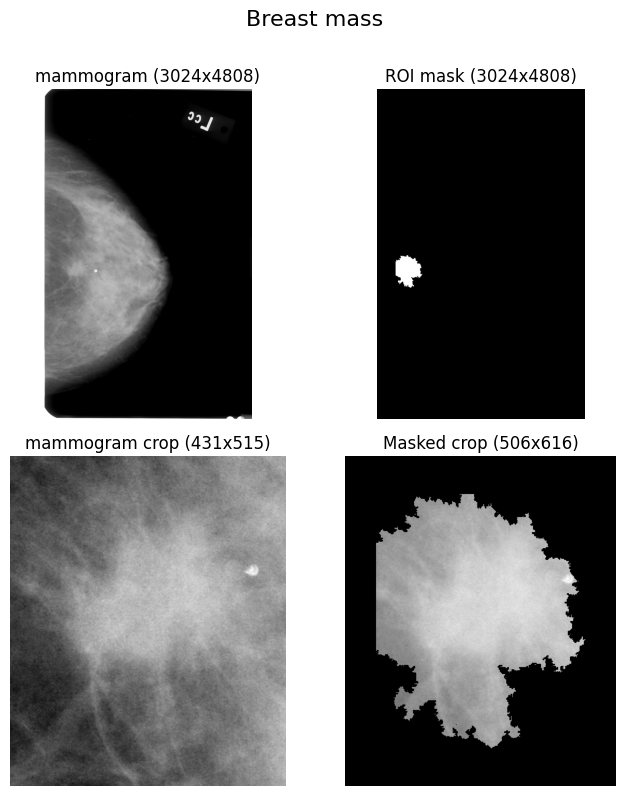

In [8]:
import matplotlib.pyplot as plt
from src.utils.image_utils import resolve_mammogram_path, resolve_cropped_mammogram_path, resolve_roi_mask_path, load_dicom, extract_roi_crop

row_mass = mass_train_df.iloc[0]

mammogram_path_mass = resolve_mammogram_path(row_mass["image file path"])
mammogram_mass = load_dicom(mammogram_path_mass)

roi_mask_path_mass = resolve_roi_mask_path(row_mass["ROI mask file path"])
roi_mask_mass = load_dicom(roi_mask_path_mass)

cropped_mammogram_path_mass = resolve_cropped_mammogram_path(row_mass["cropped image file path"])
cropped_mammogram_mass = load_dicom(cropped_mammogram_path_mass)

masked_crop_mass = extract_roi_crop(mammogram_mass, roi_mask_mass)

fig, axes = plt.subplots(2, 2, figsize=(7, 8))
for ax, img, title in zip(axes.ravel(),
    [mammogram_mass, roi_mask_mass, cropped_mammogram_mass, masked_crop_mass],
    [f'mammogram ({mammogram_mass.shape[1]}x{mammogram_mass.shape[0]})',
     f'ROI mask ({roi_mask_mass.shape[1]}x{roi_mask_mass.shape[0]})',
     f'mammogram crop ({cropped_mammogram_mass.shape[1]}x{cropped_mammogram_mass.shape[0]})',
     f'Masked crop ({masked_crop_mass.shape[1]}x{masked_crop_mass.shape[0]})']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    
plt.subplots_adjust(wspace=0.02, hspace=0.05) 
plt.suptitle("Breast mass", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

2. The full mammogram, cropped image, ROI mask and ROI mask applied to the mammogram of the first Breast Calcification of the dataset:

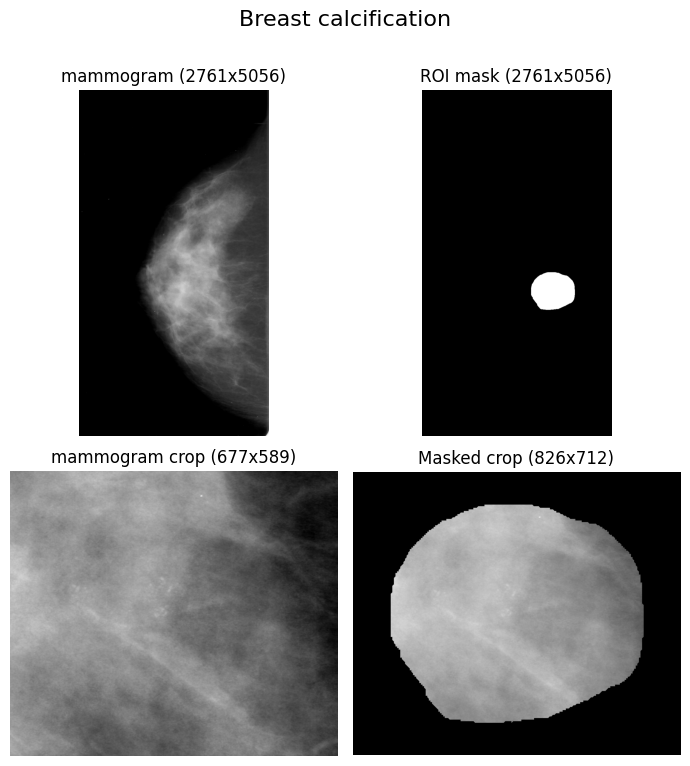

In [47]:
row_calc = calc_train_df.iloc[0]

mammogram_path_calc = resolve_mammogram_path(row_calc["image file path"])
mammogram_calc = load_dicom(mammogram_path_calc)

roi_mask_path_calc = resolve_roi_mask_path(row_calc["ROI mask file path"])
roi_mask_calc = load_dicom(roi_mask_path_calc)

cropped_mammogram_path_calc = resolve_cropped_mammogram_path(row_calc["cropped image file path"])
cropped_mammogram_calc = load_dicom(cropped_mammogram_path_calc)

masked_crop_calc = extract_roi_crop(mammogram_calc, roi_mask_calc)

fig, axes = plt.subplots(2, 2, figsize=(7, 8))
for ax, img, title in zip(axes.ravel(),
    [mammogram_calc, roi_mask_calc, cropped_mammogram_calc, masked_crop_calc],
    [f'mammogram ({mammogram_calc.shape[1]}x{mammogram_calc.shape[0]})',
     f'ROI mask ({roi_mask_calc.shape[1]}x{roi_mask_calc.shape[0]})',
     f'mammogram crop ({cropped_mammogram_calc.shape[1]}x{cropped_mammogram_calc.shape[0]})',
     f'Masked crop ({masked_crop_calc.shape[1]}x{masked_crop_calc.shape[0]})']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    
plt.subplots_adjust(wspace=0.02, hspace=0.05) 
plt.suptitle("Breast calcification", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

After this preliminar investigation, some decisions were made: 

1. Only to work with the breast masses images, and not using the calcificaiton ones. That is because both kinds of lesions look very different, and training with them may add too much noise to our model. 
2. Which image to feed the cropped image to the Visual Transformer: the full mammogram, the cropped image or the masked mammogram. Since the Visual Transformer takes the image, in 224x224 resolution, then crops it into smaller 16x16 squares and that is what is fed to the model, the cropped mammogram has the most information in the smallest area. Using full mammograms (~4800×3000) resized to 224×224 would shrink the lesion to a few pixels, and the masked image has a lot of pixels that are fully black and removes part of the context that the cropped image has. The other papers cited in the State of the art section use the cropped mammograms too, making the results more comparable.
3. Which image to compute topological descriptors from. We will compare the results both with the mammogram crop and the mask applied, and see how both of them perform.

## Implementation <a id="implementation"></a>

This section covers the project structure, implementation details, from general to more specific, which experiments will be performed and how that implementation is used in the different experiments.

This project is structured amongst different folders, and it is implemented .py files. For reproducibility purposes, the seed has been fixed in all models to be 2.

### Project structure <a id="structure"></a>

The project structure is the following

```
.
├── data                    <- Images
│   ├── raw                 <- Dataset images in dcm format
│   ├── raw_np              <- Dataset images in np format
│   ├── tda                 <- Topological descriptors of the images
│   └── preprocessed        <- Preprocessed images  
├── src
│   ├── datasets            <- Implements torch.dataset
│   ├── models              <- Implements nn.Module for the ViT and ViT + TDA
│   ├── tda                 <- To compute topological descriptors
│   ├── training            <- To train and evaluate the model
│   └── utils               <- Image and preprocessing utils
├── checkpoints             <- Experiment results
├── .gitignore
├── notebook.ipynb          <- This notebook 
├── notebook.html           <- This notebook, exported to html 
├── README.md               <- Setup instructions and brief description of the project
├── requirements.txt        <- List of dependencies
└── TFM.pdf                 <- Msc. Thesis
```

### Implementation details <a id="details"></a>

In a file-by-file analysis:

* **` notebook.ipynb`:** this notebook. Describes the project and triggers the experiment execution. 
* **`src/utils/`:**
  * **`image_utils.py`:** has seven functions to take care of image loading and path resolution:
    * `load_dicom(path)`: given a full path, it uses [pydicom](https://pydicom.github.io/) to load the image and transform it into a [numpy matrix](https://numpy.org/). It normalizes the image to have values between 0 and 255.
    * `get_all_dcm_files_with_size(rel_path)`: given a relative path, it builds the full path using the `BASE_PATH` defined in the same `image_utils.py` file, whilst taking into account the long path limitations in Windows OS. With the [os](https://docs.python.org/3/library/os.html) module it extracts all files with .dcm extension in said path, and sorts them by size (as described above, it will be used to distinguish masks from cropped mammograms).
    * `resolve_mammogram_path(rel_path)`: extracts the mammogram path from a relative path, taking into account that the file name might be wrong. If more than one files are found in the provided folder, it raises an exception.
    * `resolve_cropped_mammogram_path(rel_path)`: extracts the cropped mammogram path from a relative path, taking into account that the file name might be wrong. If one file is found in the path, it returns the path. If two files are found, it returns the path to the smallest one. If more than two files are found in the provided folder, it raises an exception.
    * `resolve_roi_mask_path(rel_path)`: extracts the ROI mask path from a relative path, taking into account that the file name might be wrong. If one file is found in the path, it returns the path. If two files are found, it returns the path to the biggest one. If more than two files are found in the provided folder, it raises an exception.
    * `cache_cropped_mammogram_images_as_np_arrays(save_dir, df)`: given a dataset with "cropped image file path" and "pathology" columns, it (1) resolves all the paths to the cropped mammogram images (2) converts them into numpy arrays and saves them in the `save_dir` provided and (3) saves a `.csv` file in that same folder with two columns: path to the converted image and the corresponding label, that is 1 if it is malignant and 0 if it is either benign or Benign without callback. This function is used to reduce the time loading `dcm` files for every execution.
    * `extract_roi_crop(mammogram, mask, padding_ratio=0.15)`: extracts the ROI crop from a mammogram and applies the mask to it.
  * **`preprocess.py`:** contains three functions for image preprocessing:
    * `apply_clahe(image)`: applies [Contrast Limited Adaptive Histogram Equalization (CLAHE)](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html) to a grayscale image using [cv2.createCLAHE](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html) with `clipLimit=2.0` and `tileGridSize=(8,8)` to enhance local contrast.
    * `denoise(image)`: applies a [Gaussian blur](https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html) with a 5×5 kernel using [cv2.GaussianBlur](https://docs.opencv.org/4.x/d4/d13/tutorial_py_filtering.html) to reduce noise.
    * `preprocess(image)`: chains `apply_clahe` followed by `denoise`, returning the preprocessed image.
* **`src/models/`:**
  * **`vit_model.py`:** defines the `ViTClassifier` class, a [PyTorch nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) that wraps a pretrained Vision Transformer. It uses [timm.create_model](https://huggingface.co/docs/timm/reference/models#timm.create_model) to load [vit_base_patch16_224](https://huggingface.co/google/vit-base-patch16-224) (ViT-B/16, pretrained on ImageNet). The classification head is replaced with a single [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layer that maps from the ViT's hidden dimension (768) to 1 output (binary classification logit). The `forward` method passes the input through the full ViT and returns the raw logit (during training, [BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) applies sigmoid internally).
  * **`fusion_model.py`:** defines two fusion architectures for combining ViT image features with TDA topological features:
    * `FusionModel`: combines a Visual Transformer to process the images with a Linear Layer to process the vectorial topological descriptors. It loads the same `vit_base_patch16_224` backbone but replaces the head with [nn.Identity](https://pytorch.org/docs/stable/generated/torch.nn.Identity.html) to extract the 768-dimensional CLS token. A separate TDA branch (`tda_fc`, an [nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layer) projects the flattened TDA vector to 128 dimensions. The `forward` method concatenates both feature vectors using [torch.cat](https://pytorch.org/docs/stable/generated/torch.cat.html) and passes the result through a classifier head: `Linear(896, 256) → ReLU → Linear(256, 1)`. The constructor accepts a `tda_input_dim` parameter (default 1400) to match the vector descriptor dimensionality.
    * `DualViTFusionModel`: combines a Visual Transformer to process the images with another Visual Transformer to process the Persistence Images (PI). Both og them are separate [vit_base_patch16_224](https://huggingface.co/google/vit-base-patch16-224) branches. Both heads are replaced with [nn.Identity](https://pytorch.org/docs/stable/generated/torch.nn.Identity.html) to extract 768-dim CLS tokens. The `forward` method adapts the PI input (shape `batch, 2, 100, 100` for H0 and H1 homology dimensions) to 3-channel ViT input by padding with a zero channel and resizing to 224×224 using [F.interpolate](https://pytorch.org/docs/stable/generated/torch.nn.functional.interpolate.html); find more details on the  [Experiments](#experiments) section below. The two CLS tokens are concatenated via [torch.cat](https://pytorch.org/docs/stable/generated/torch.cat.html) and passed through a classifier: `Linear(1536, 256) → ReLU → Linear(256, 1)`.
* **`src/datasets/experiment_dataset.py`:** defines the `ExperimentDataset` class, a [PyTorch Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) that loads precomputed `.npy` images using [numpy.load](https://numpy.org/doc/stable/reference/generated/numpy.load.html). Constructor parameters:
  * `image_paths`, `labels`: lists of image paths and binary labels.
  * `tda_paths` (defaults to `None`): list of paths to precomputed TDA `.npy` files. When provided, `__getitem__` returns a 3-tuple `(image, tda, label)` instead of `(image, label)`.
  * `use_preprocessing` (defaults to `False`): if `True`, applies the CLAHE + denoise pipeline from `preprocess.py`.
  * `augment` (defaults to `False`): if `True`, applies basic augmentation — random horizontal flip via [numpy.fliplr](https://numpy.org/doc/stable/reference/generated/numpy.fliplr.html) and random vertical flip via [numpy.flipud](https://numpy.org/doc/stable/reference/generated/numpy.flipud.html).
  * `aggressive_augmentation` (defaults to `False`): if `True`, applies additional augmentation on top of basic flips — random rotation (±15°) via [cv2.getRotationMatrix2D](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html) and [cv2.warpAffine](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html), random zoom/crop (85–100% scale), and random shear (±0.1).
  * `tda_as_image` (defaults to `False`): if `True`, the loaded TDA array is kept as a multi-dimensional array (for `DualViTFusionModel`). If `False`, it is flattened to a 1D vector (for `FusionModel`).
  * `img_size` (defaults to `224`): images are resized to `img_size`x`img_size` using [cv2.resize](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html), stacked to 3 channels (grayscale → RGB), normalized to [0, 1], and converted to [torch.Tensor](https://pytorch.org/docs/stable/tensors.html).
* **`src/training/experiment_runner.py`:** contains the full training pipeline with four functions:
  * `get_class_weights(labels)`: computes `pos_weight` for [BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) as the ratio of negative to positive samples, to address class imbalance in the dataset.
  * `train_one_epoch(model, dataloader, optimizer, criterion, device)`: runs one training epoch. Calls `model.train()`, iterates over batches, computes loss, backpropagates, and updates weights. Handles both 2-tuple (ViT-only) and 3-tuple (fusion) batches.
  * `evaluate(model, dataloader, criterion, device)`: runs evaluation with `model.eval()` and [torch.no_grad](https://pytorch.org/docs/stable/generated/torch.no_grad.html), to prevent computing the gradient, since `Tensor.backward()` is not used. Computes loss, applies [torch.sigmoid](https://pytorch.org/docs/stable/generated/torch.sigmoid.html) to get probabilities, and calculates [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), [F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html), and [AUC-ROC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) using [scikit-learn](https://scikit-learn.org/). Returns metrics, true labels, and predicted probabilities.
  * `run_experiment(model_fn, train_dataset, test_dataset, config)`: orchestrates a full experiment. Splits training data into train/val using [StratifiedShuffleSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html) (85/15). Creates [DataLoaders](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader), initializes the model, loss (with class weights), [Adam optimizer](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html), and [CosineAnnealingLR scheduler](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html). Trains with early stopping (patience-based on validation loss), saves the best model checkpoint using [torch.save](https://pytorch.org/docs/stable/generated/torch.save.html) in the `checkpoints` folder, evaluates on the test set, and persists all results (metrics, training history, predictions) to a JSON file using [json.dump](https://docs.python.org/3/library/json.html#json.dump) in the `checkpoints` folder, for survival across kernel restarts.
* **`src/tda/tda_features.py`:** defines six functions for computing topological descriptors from grayscale images:
  * `compute_persistence_image(image)`: uses [CubicalPersistence](https://giotto-ai.github.io/gtda-docs/latest/modules/generated/homology/gtda.homology.CubicalPersistence.html) from [giotto-tda](https://giotto-ai.github.io/gtda-docs/latest/) to compute persistent homology (tracking connected components and holes across intensity thresholds). It transforms the resulting persistence diagram into a fixed-size [PersistenceImage](https://giotto-ai.github.io/gtda-docs/latest/modules/generated/diagrams/gtda.diagrams.PersistenceImage.html) of shape `(2, 100, 100)`: one 100×100 image per homology dimension (H0 and H1).
  * `compute_vector_descriptors(image)`: uses [gudhi.CubicalComplex](https://gudhi.inria.fr/python/latest/cubical_complex_ref.html) to compute persistent homology, then extracts compact topological summaries for each homology dimension (H0 and H1) using [gudhi.representations.BettiCurve](https://gudhi.inria.fr/python/latest/representations.html#gudhi.representations.BettiCurve), [Landscape](https://gudhi.inria.fr/python/latest/representations.html#gudhi.representations.Landscape) (5 landscapes), and [Silhouette](https://gudhi.inria.fr/python/latest/representations.html#gudhi.representations.Silhouette), all at resolution 100. Returns a 1D [numpy](https://numpy.org/) array of 1400 dimensions (2×100 Betti + 2×500 Landscape + 2×100 Silhouette).
  * `precompute_tda_cropped_image(cache_csv_path, tda_dir)`: iterates over cached `.npy` crops, computes persistence images via `compute_persistence_image`, saves each as `.npy`, and adds a `tda_crop_path` column to the cache CSV.
  * `precompute_tda_masked_mammography(cache_csv_path, df, tda_dir)`: loads full mammograms and ROI masks from the original DataFrame, applies `extract_roi_crop` to produce masked crops, computes persistence images, saves them, and adds a `tda_masked_path` column to the cache CSV.
  * `precompute_tda_vector_descriptors_cropped(cache_csv_path, tda_dir)`: same as `precompute_tda_cropped_image` but uses `compute_vector_descriptors` instead. Adds a `tda_vec_crop_path` column.
  * `precompute_tda_vector_descriptors_masked(cache_csv_path, df, tda_dir)`: same as `precompute_tda_masked_mammography` but uses `compute_vector_descriptors` instead. Adds a `tda_vec_masked_path` column.
* **`checkpoints`:** contains the files persisted by `run_experiment()` after each experiment: a json file with the results, as well as the best checkpoint obtained, in `pt` format. Each json file contains: test metrics (loss, accuracy, F1, AUC), training history (train loss, val loss, val AUC per epoch), the checkpoint path, and the raw test predictions (`y_true`, `y_prob`) for confusion matrices and ROC curves.

### Experiments <a id="experiments"></a>
The first hypothesis to be tested is 

<p style="text-align:center"><i> <strong>H1:</strong> Image preprocessing techniques (noise reduction and contrast enhancement) positively impact the classification accuracy of a Vision Transformer model. </i></p>

To do so, we define three experiments:

|Id|Experiment name|Description|
|-|-|-|
|E1|ViT baseline|ViT model with no preprocessing, data augmentation applied to the training set|
|E2|ViT preprocessing|E1 + CLAHE and Denoise, defined in `preprocess.py`|
|E3|ViT preprocessing + aggressive data augmentation|E2 + aggressive data augmentation applied to the training set|

To build a three-channel input for the ViT, the grayscale image is stacked in the three channels [image, image, image]. The results of these experiments are compared to the ones cited in the state of the art portion of the thesis.

| Study | AUC | ACC | F1 |
|-------|-----|-----|----|
| Paper 1 (VGG16 + heavy augmentation to 60K images) | 0.844 | 0.844 | 0.85 |
| Paper 2 (EfficientNet-B2, minimal augmentation) | 0.679 | 0.650 | — |
| Paper 3 (BiT + attention + text metadata) | 0.878 | 0.796 | 0.780 |

It is specially interesting how the results from E1 and E2 compare to Papers 1 and 2, and to see E3 compared with Paper 1 and Paper 3. As defined above, the ViT will be fed the mammogram cropped images.

The second hypothesis to be tested is:

<p style="text-align:center"><i> <strong>H2:</strong> The incorporation of topological descriptors derived from TDA provides complementary structural information that improves classification performance compared to a standard Vision Transformer.</i></p>

To test this, two kinds of tests are performed; each of them takes as the base model the best of E1, E2, E3. 

* **Two ViT branches:** following what [_TDA-ViT: A Transformer-Based Framework for Unified Urdu Text Recognition via Topological and Visual Feature Fusion_](https://ieeexplore.ieee.org/document/11202936) suggests, persistence images will be computed for every image and fed into the Visual Transformer. The experiments performed are the following:  using two ViT branches (one for mammogram, one for persistence image), concatenating the output tokens and feeding them to a classifier. 
To obtain three channels from the Persistance Image (PI), that has two channels, the PI is padded with a zero channel: [H0, H1, 0]. Other options like having only one ViT with [original_crop, H0, H1] were also considered, but disregarded as the ViT convolutes the input in the first layer for each patch: 16×16×3 → 768-dim, and mixing all channels makes little sense, as PIs live in persistence space (birth/death axes), not pixel space (position (50,50) in the PI has no spatial correspondence to position (50,50) in the original image.)
Two experiments are performed with this approach:

|Id|Experiment name|Description|
|-|-|-|
|E4|Best of (E1, E2, E3) + Persistence Images in mammogram crop|Vit fed with the mammogram crops + Vit fed with persistance images of said crops, outouts concatenated and fed into a classifier|
|E5|Best of (E1, E2, E3) + Persistence Images in masked mammogram|Vit fed with the mammogram crops + Vit fed with persistance images of masked mammogram, outouts concatenated and fed into a classifier|

E4 and E5 allows us to see which of the embeddings gets better results, and to compare them with the best of the three first experiments.

* **ViT + Classifier:** instead of using image persistance values, a ViT is used for mammogram, outputing a vector, and linear layer for compact TDA vector descriptors (1400-dim: Betti curves 2×100 + Landscapes 2×500 + Silhouettes 2×100, for H0 and H1 each), concatenated. The output of both of them is concatenated and and passed through a classifier: `Linear(1536, 256) → ReLU → Linear(256, 1)`.

|Id|Experiment name|Description|
|-|-|-|
|E6|Best of (E1, E2, E3) + TDA vector in mammogram crop|ViT fed with the mammogram crops + Vectorial topological descriptors of said crop, outputs concatenated and fed into a classifier|
|E7|Best of (E1, E2, E3) + TDA vctor in masked mammogram|ViT fed with the mammogram crops + Vectorial topological descriptors of masked mamogram, outputs concatenated and fed into a classifier|

#### Preprocessing <a id="preprocessing"></a>

To relieve the load in the training that comes from loading dcm files, first we transform all of them into normalized numpy arrays and store them in `data/raw_np/mass_<train/test>`

The persistance images computed for every cropped mammogram are stored in `data/tda/mass_<train/test>`. To add clarity, the first cell below shows what persistance images look like for a mammograph.

The vectorial descriptors for each image are stored in `data/tda/mass_<train/test>`.
To add clarity, the second cell below shows what persistance vectors look like for a mammograph.

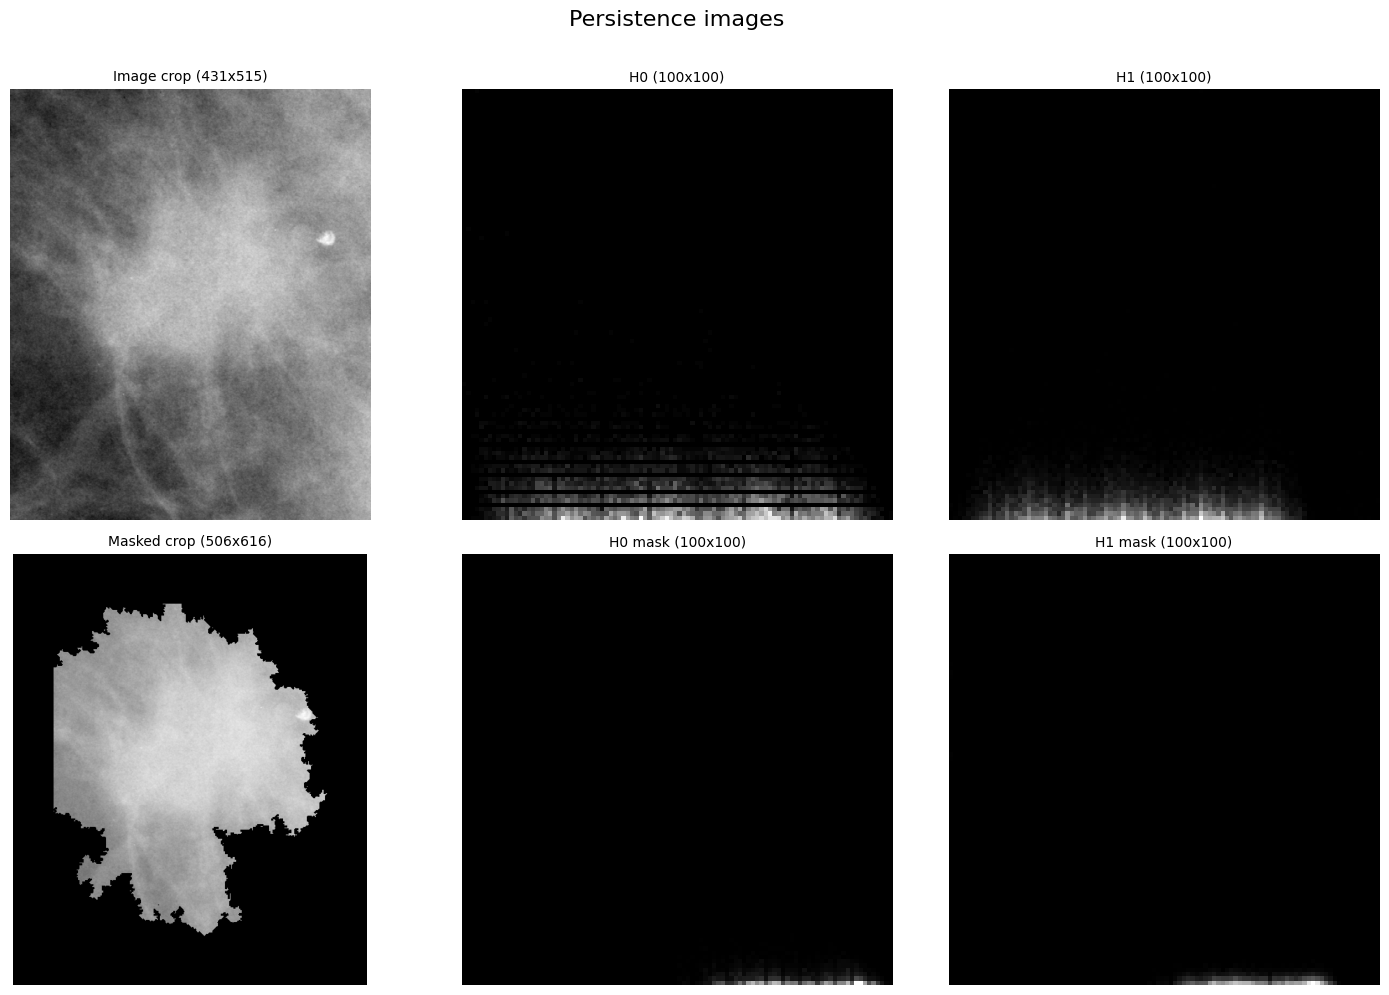

In [9]:
from src.tda.tda_features import compute_persistence_image

pi_0, pi_1 = compute_persistence_image(cropped_mammogram_mass)
pi_0_mask, pi_1_mask = compute_persistence_image(masked_crop_mass)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, im, title in zip(
    axes.ravel(),
    [cropped_mammogram_mass, pi_0, pi_1,
     masked_crop_mass, pi_0_mask, pi_1_mask],
    [f'Image crop ({cropped_mammogram_mass.shape[1]}x{cropped_mammogram_mass.shape[0]})',
     f'H0 ({pi_0.shape[1]}x{pi_0.shape[0]})',
     f'H1 ({pi_1.shape[1]}x{pi_1.shape[0]})',
     f'Masked crop ({masked_crop_mass.shape[1]}x{masked_crop_mass.shape[0]})',
     f'H0 mask ({pi_0_mask.shape[1]}x{pi_0_mask.shape[0]})',
     f'H1 mask ({pi_1_mask.shape[1]}x{pi_1_mask.shape[0]})']
):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.15)
plt.suptitle("Persistence images", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()

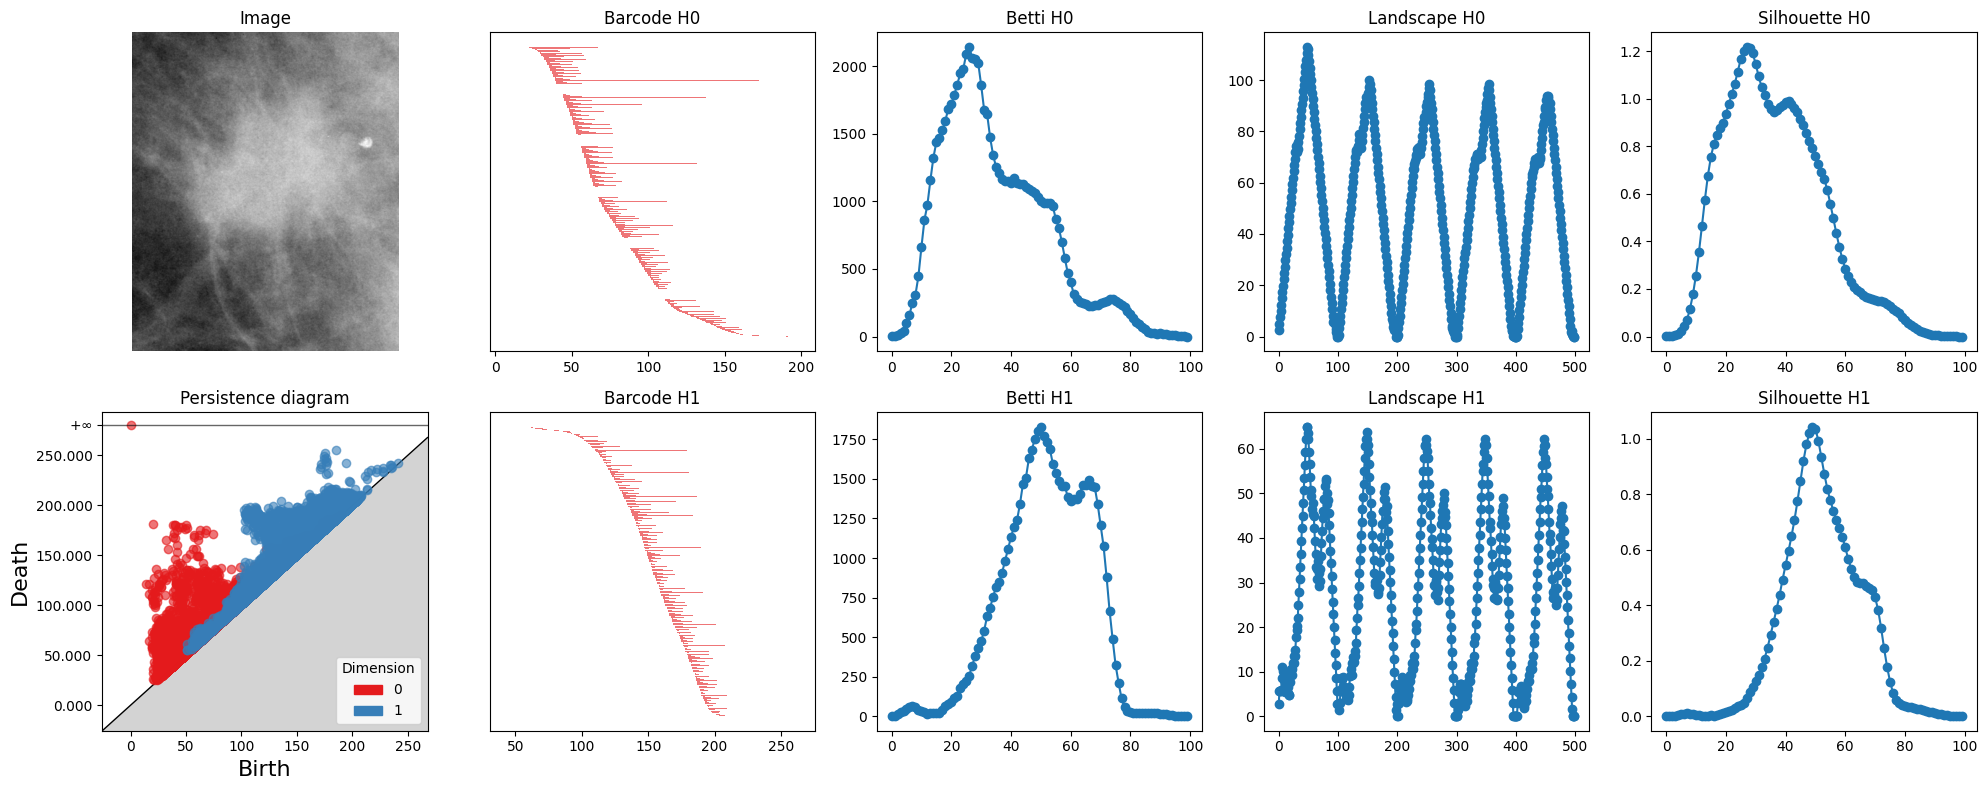

In [11]:
%matplotlib inline

import numpy as np
import gudhi as gd  
import gudhi.representations
import matplotlib.pyplot as plt

cc = gd.CubicalComplex(
    dimensions=cropped_mammogram_mass.shape,
    top_dimensional_cells=cropped_mammogram_mass.flatten().astype(float)
)
persistence = cc.persistence()

diagrams = {
    0: np.array([p for p in cc.persistence_intervals_in_dimension(0) if p[1] != float('inf')]),
    1: np.array([p for p in cc.persistence_intervals_in_dimension(1) if p[1] != float('inf')])
}

resolution = 100
n_landscapes = 5

reprs = {
    "Betti": lambda p: gd.representations.BettiCurve(resolution=resolution)(p).flatten(),
    "Landscape": lambda p: gd.representations.Landscape(num_landscapes=n_landscapes, resolution=resolution)(p).flatten(),
    "Silhouette": lambda p: gd.representations.Silhouette(resolution=resolution)(p).flatten()
}

features = {
    dim: {name: fn(diagrams[dim]) for name, fn in reprs.items()}
    for dim in diagrams
}

# --- Plot ---
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Column 0: image + diagram
axes[0, 0].imshow(cropped_mammogram_mass, cmap='gray')
axes[0, 0].set_title('Image')
axes[0, 0].axis('off')

gd.plot_persistence_diagram(persistence, legend=True, axes=axes[1, 0])
axes[1, 0].set_title('Persistence diagram')

# Column 1: barcodes
for dim in [0, 1]:
    gd.plot_persistence_barcode(diagrams[dim], axes=axes[dim, 1])
    axes[dim, 1].set_title(f'Barcode H{dim}')

# Columns 2–4: features
column = 2
for name in ["Betti", "Landscape", "Silhouette"]:
    for dim in [0, 1]:
        y = features[dim][name]
        
        title = f'{name} H{dim}'
        
        axes[dim, column].plot(y, marker='o')
        axes[dim, column].set_title(title)
    
    column += 1

plt.tight_layout()
plt.show()

In [2]:
MASS_TRAIN_SAVE_DIR = "data/raw_np/mass_train"
MASS_TEST_SAVE_DIR = "data/raw_np/mass_test"

MASS_TRAIN_TDA_CROP_DIR = "data/tda/crop/mass_train"
MASS_TEST_TDA_CROP_DIR = "data/tda/crop/mass_test"
MASS_TRAIN_TDA_MASKED_DIR = "data/tda/masked/mass_train"
MASS_TEST_TDA_MASKED_DIR = "data/tda/masked/mass_test"

In [ ]:
from src.utils.image_utils import cache_cropped_mammogram_images_as_np_arrays

cache_cropped_mammogram_images_as_np_arrays(MASS_TRAIN_SAVE_DIR, mass_train_df)
cache_cropped_mammogram_images_as_np_arrays(MASS_TEST_SAVE_DIR, mass_test_df)

1318it [00:04, 310.27it/s]
378it [00:01, 301.21it/s]


In [3]:
from src.tda.tda_features import precompute_tda_cropped_image, precompute_tda_masked_mammogram
from src.tda.tda_features import precompute_tda_vector_descriptors_cropped, precompute_tda_vector_descriptors_masked

# Precompute persistence images for cropped lesions (E4)
precompute_tda_cropped_image(MASS_TRAIN_SAVE_DIR + '/cached.csv', MASS_TRAIN_TDA_CROP_DIR)
precompute_tda_cropped_image(MASS_TEST_SAVE_DIR + '/cached.csv', MASS_TEST_TDA_CROP_DIR)

# Precompute persistence images for masked crops (E5)
precompute_tda_masked_mammogram(MASS_TRAIN_SAVE_DIR + '/cached.csv', mass_train_df, MASS_TRAIN_TDA_MASKED_DIR)
precompute_tda_masked_mammogram(MASS_TEST_SAVE_DIR + '/cached.csv', mass_test_df, MASS_TEST_TDA_MASKED_DIR)

# Precompute vector descriptors for cropped lesions (E6)
precompute_tda_vector_descriptors_cropped(MASS_TRAIN_SAVE_DIR + '/cached.csv', MASS_TRAIN_TDA_CROP_DIR)
precompute_tda_vector_descriptors_cropped(MASS_TEST_SAVE_DIR + '/cached.csv', MASS_TEST_TDA_CROP_DIR)

# Precompute vector descriptors for masked crops (E7)
precompute_tda_vector_descriptors_masked(MASS_TRAIN_SAVE_DIR + '/cached.csv', mass_train_df, MASS_TRAIN_TDA_MASKED_DIR)
precompute_tda_vector_descriptors_masked(MASS_TEST_SAVE_DIR + '/cached.csv', mass_test_df, MASS_TEST_TDA_MASKED_DIR)

print('All TDA precomputation done.')

100%|██████████| 378/378 [03:24<00:00,  1.85it/s]

All TDA precomputation done.


#### Execution <a id="execution"></a>

This section takes care of executing each of the experiments described above. The first cell loads the cached data and sets the `SEED` that is used (`2`).

Each of the experiment execution cells follows the same structure:

1. Defines the train and test Datasets using the ExperimentDataset class defined in `src/datasets/`. It passes the different paths and values depending on the experiment.
2. Calls `run_experiment` with both datasets and the right model for each experiment. In the `config` parameter, the `SEED` is set, as well as 30 epochs with a patience of 5.

After the first three experiments are run, a little comparative analysis is performed to decide which of the ViTs is used for experiments four to seven.

In [3]:
import pandas as pd
from src.datasets.experiment_dataset import ExperimentDataset
from src.models.vit_model import ViTClassifier
from src.training.experiment_runner import run_experiment

SEED = 2
train_cache = pd.read_csv(MASS_TRAIN_SAVE_DIR + '/cached.csv')
test_cache = pd.read_csv(MASS_TEST_SAVE_DIR + '/cached.csv')

In [ ]:
# --- E1: ViT baseline (no preprocessing, no TDA) ---
print('=== E1: ViT baseline ===')
train_ds = ExperimentDataset(
    image_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=False, augment=True)
test_ds = ExperimentDataset(
    image_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=False, augment=False)

run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E1', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E1: ViT baseline ===
  [E1] Epoch 1/30  train_loss=0.7776  val_loss=0.7135  val_auc=0.5826
  [E1] Epoch 2/30  train_loss=0.7526  val_loss=0.7199  val_auc=0.5964
  [E1] Epoch 3/30  train_loss=0.7255  val_loss=0.7251  val_auc=0.6041
  [E1] Epoch 4/30  train_loss=0.7351  val_loss=0.7867  val_auc=0.6053
  [E1] Epoch 5/30  train_loss=0.7332  val_loss=0.7161  val_auc=0.6120
  [E1] Epoch 6/30  train_loss=0.7224  val_loss=0.7146  val_auc=0.6283
  [E1] Early stopping at epoch 6
  [E1] TEST  acc=0.3995  f1=0.5505  auc=0.5346


In [ ]:
# --- E2: ViT + preprocessing ---
print('=== E2: ViT + preprocessing ===')
train_ds = ExperimentDataset(
    image_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=True, augment=True)
test_ds = ExperimentDataset(
    image_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=True, augment=False)

run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E2', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E2: ViT + preprocessing ===
  [E2] Epoch 1/30  train_loss=0.7946  val_loss=0.7128  val_auc=0.6078
  [E2] Epoch 2/30  train_loss=0.7487  val_loss=0.7188  val_auc=0.6515
  [E2] Epoch 3/30  train_loss=0.7236  val_loss=0.7191  val_auc=0.6746
  [E2] Epoch 4/30  train_loss=0.7349  val_loss=0.7758  val_auc=0.6649
  [E2] Epoch 5/30  train_loss=0.7286  val_loss=0.7039  val_auc=0.6779
  [E2] Epoch 6/30  train_loss=0.7093  val_loss=0.7264  val_auc=0.6736
  [E2] Epoch 7/30  train_loss=0.7106  val_loss=0.7451  val_auc=0.6567
  [E2] Epoch 8/30  train_loss=0.7155  val_loss=0.6868  val_auc=0.6637
  [E2] Epoch 9/30  train_loss=0.6934  val_loss=0.6947  val_auc=0.6326
  [E2] Epoch 10/30  train_loss=0.6923  val_loss=0.7035  val_auc=0.6119
  [E2] Epoch 11/30  train_loss=0.7063  val_loss=0.6810  val_auc=0.6748
  [E2] Epoch 12/30  train_loss=0.6817  val_loss=0.6745  val_auc=0.6681
  [E2] Epoch 13/30  train_loss=0.7014  val_loss=0.7148  val_auc=0.6600
  [E2] Epoch 14/30  train_loss=0.6835  val_loss=0.7140

In [4]:
# --- E3: ViT + preprocessing + aggressive augmentation ---
print('=== E3: ViT + preprocessing + aggressive augmentation ===')
train_ds = ExperimentDataset(
    image_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    use_preprocessing=True, augment=True, aggressive_augmentation=True)
test_ds = ExperimentDataset(
    image_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    use_preprocessing=True, augment=False, aggressive_augmentation=False)

run_experiment(
    model_fn=ViTClassifier,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E3', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E3: ViT + preprocessing + aggressive augmentation ===
  [E3] Epoch 1/30  train_loss=0.7632  val_loss=0.7144  val_auc=0.5869
  [E3] Epoch 2/30  train_loss=0.7612  val_loss=0.7331  val_auc=0.5895
  [E3] Epoch 3/30  train_loss=0.7258  val_loss=0.7256  val_auc=0.6373
  [E3] Epoch 4/30  train_loss=0.7374  val_loss=0.7892  val_auc=0.6189
  [E3] Epoch 5/30  train_loss=0.7334  val_loss=0.7160  val_auc=0.6253
  [E3] Epoch 6/30  train_loss=0.7216  val_loss=0.7099  val_auc=0.6162
  [E3] Epoch 7/30  train_loss=0.7201  val_loss=0.7283  val_auc=0.6614
  [E3] Epoch 8/30  train_loss=0.7307  val_loss=0.7252  val_auc=0.6298
  [E3] Epoch 9/30  train_loss=0.7149  val_loss=0.7109  val_auc=0.6208
  [E3] Epoch 10/30  train_loss=0.7304  val_loss=0.7122  val_auc=0.6436
  [E3] Epoch 11/30  train_loss=0.7207  val_loss=0.6938  val_auc=0.6746
  [E3] Epoch 12/30  train_loss=0.7202  val_loss=0.7212  val_auc=0.5910
  [E3] Epoch 13/30  train_loss=0.7429  val_loss=0.7470  val_auc=0.6016
  [E3] Epoch 14/30  train_lo

{'test': {'loss': 0.6893273169795672,
  'accuracy': 0.6137566137566137,
  'f1': 0.5100671140939598,
  'auc': 0.6555643902582678},
 'history': {'train_loss': [0.7632498332432338,
   0.7611580312252044,
   0.7258058786392212,
   0.7373903180871691,
   0.7333724038941519,
   0.7215522944927215,
   0.7200527472155435,
   0.7307216754981449,
   0.7148872741631099,
   0.7304318581308638,
   0.7206736087799073,
   0.7201720416545868,
   0.7429393053054809,
   0.7226431156907763,
   0.7304006312574659,
   0.7272765449115208],
  'val_loss': [0.7144476496256315,
   0.7330905336600083,
   0.725639269902156,
   0.7891850838294396,
   0.7160018453231225,
   0.7098886829156142,
   0.7282700355236347,
   0.7252485293608445,
   0.7109036170519315,
   0.7121791014304528,
   0.6938041265194232,
   0.7212008833885193,
   0.7470000156989465,
   0.7280464493311368,
   0.7529190411934485,
   0.715059349170098],
  'val_auc': [0.586907679738562,
   0.5894607843137255,
   0.6372549019607844,
   0.6188725490196

## Analysis

In all of them the early stopping was triggered, meaning there was a risk of overfitting. E2 is the best performant of the three, and is used as the base for TDA experiments (E4–E7).

| Experiment Id | ACC | F1 | AUC |
|-------|-----|-----|----|
| E1 | 0.3995 | 0.5505 | 0.5346 |
| E2 | **0.6720** | **0.6196** | **0.7228** |
| E3 | 0.6138 | 0.5101 | 0.6556 |


In [ ]:
from src.models.fusion_model import DualViTFusionModel
from src.training.experiment_runner import run_experiment

print('=== E4: ViT (preprocessed) + PI of cropped lesion ===')
train_ds = ExperimentDataset(
    image_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    tda_paths=train_cache['tda_crop_path'].tolist(),
    use_preprocessing=True, augment=True, tda_as_image=True)
test_ds = ExperimentDataset(
    image_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    tda_paths=test_cache['tda_crop_path'].tolist(),
    use_preprocessing=True, augment=False, tda_as_image=True)

run_experiment(
    model_fn=DualViTFusionModel,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E4', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E4: ViT (preprocessed) + PI of cropped lesion ===
  [E4] Epoch 1/30  train_loss=0.7574  val_loss=0.7044  val_auc=0.5954
  [E4] Epoch 2/30  train_loss=0.7222  val_loss=0.7039  val_auc=0.6109
  [E4] Epoch 3/30  train_loss=0.7128  val_loss=0.7376  val_auc=0.6037
  [E4] Epoch 4/30  train_loss=0.7065  val_loss=0.7116  val_auc=0.5985
  [E4] Epoch 5/30  train_loss=0.6909  val_loss=0.7119  val_auc=0.6129
  [E4] Epoch 6/30  train_loss=0.6905  val_loss=0.7182  val_auc=0.5988
  [E4] Epoch 7/30  train_loss=0.6745  val_loss=0.7370  val_auc=0.5845
  [E4] Early stopping at epoch 7
  [E4] TEST  acc=0.5820  f1=0.3923  auc=0.5687


In [ ]:
from src.models.fusion_model import DualViTFusionModel
from src.training.experiment_runner import run_experiment

print('=== E5: ViT (preprocessed) + PI of masked crop ===')
train_ds = ExperimentDataset(
    image_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    tda_paths=train_cache['tda_masked_path'].tolist(),
    use_preprocessing=True, augment=True, tda_as_image=True)
test_ds = ExperimentDataset(
    image_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    tda_paths=test_cache['tda_masked_path'].tolist(),
    use_preprocessing=True, augment=False, tda_as_image=True)

run_experiment(
    model_fn=DualViTFusionModel,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E5', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E5: ViT (preprocessed) + PI of masked crop ===
  [E5] Epoch 1/30  train_loss=0.7608  val_loss=0.7171  val_auc=0.5653
  [E5] Epoch 2/30  train_loss=0.7424  val_loss=0.7297  val_auc=0.5627
  [E5] Epoch 3/30  train_loss=0.7297  val_loss=0.7606  val_auc=0.6336
  [E5] Epoch 4/30  train_loss=0.7006  val_loss=0.7046  val_auc=0.6285
  [E5] Epoch 5/30  train_loss=0.6897  val_loss=0.7106  val_auc=0.6685
  [E5] Epoch 6/30  train_loss=0.6830  val_loss=0.6685  val_auc=0.6875
  [E5] Epoch 7/30  train_loss=0.6627  val_loss=0.6696  val_auc=0.6886
  [E5] Epoch 8/30  train_loss=0.6402  val_loss=0.7505  val_auc=0.6387
  [E5] Epoch 9/30  train_loss=0.6175  val_loss=0.6745  val_auc=0.6593
  [E5] Epoch 10/30  train_loss=0.6234  val_loss=0.6959  val_auc=0.6494
  [E5] Epoch 11/30  train_loss=0.5534  val_loss=0.7482  val_auc=0.6528
  [E5] Early stopping at epoch 11
  [E5] TEST  acc=0.5926  f1=0.4500  auc=0.5792


In [ ]:
from src.models.fusion_model import FusionModel
from src.training.experiment_runner import run_experiment

print('=== E6: ViT (preprocessed) + vector descriptors of cropped lesion ===')
train_ds = ExperimentDataset(
    image_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    tda_paths=train_cache['tda_vec_crop_path'].tolist(),
    use_preprocessing=True, augment=True, tda_as_image=False)
test_ds = ExperimentDataset(
    image_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    tda_paths=test_cache['tda_vec_crop_path'].tolist(),
    use_preprocessing=True, augment=False, tda_as_image=False)

run_experiment(
    model_fn=FusionModel,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E6', 'seed': SEED, 'epochs': 30, 'patience': 5})

=== E6: ViT (preprocessed) + vector descriptors of cropped lesion ===
  [E6] Epoch 1/30  train_loss=1.6432  val_loss=1.5733  val_auc=0.6195
  [E6] Epoch 2/30  train_loss=1.1761  val_loss=1.3836  val_auc=0.5848
  [E6] Epoch 3/30  train_loss=0.9386  val_loss=1.0162  val_auc=0.5557
  [E6] Epoch 4/30  train_loss=0.7817  val_loss=1.0628  val_auc=0.5856
  [E6] Epoch 5/30  train_loss=0.7090  val_loss=0.9385  val_auc=0.5777
  [E6] Epoch 6/30  train_loss=0.7255  val_loss=0.9605  val_auc=0.5486
  [E6] Epoch 7/30  train_loss=0.6055  val_loss=1.0956  val_auc=0.5190
  [E6] Epoch 8/30  train_loss=0.5877  val_loss=0.9474  val_auc=0.5798
  [E6] Epoch 9/30  train_loss=0.5693  val_loss=0.9782  val_auc=0.5599
  [E6] Epoch 10/30  train_loss=0.5480  val_loss=0.9124  val_auc=0.5616
  [E6] Epoch 11/30  train_loss=0.5173  val_loss=0.9395  val_auc=0.5473
  [E6] Epoch 12/30  train_loss=0.4671  val_loss=0.9497  val_auc=0.5635
  [E6] Epoch 13/30  train_loss=0.4845  val_loss=1.0019  val_auc=0.5888
  [E6] Epoch 14/

In [ ]:
from src.models.fusion_model import FusionModel
from src.training.experiment_runner import run_experiment

print('=== E7: ViT (preprocessed) + vector descriptors of masked crop ===')
train_ds = ExperimentDataset(
    image_paths=train_cache['path'].tolist(),
    labels=train_cache['label'].tolist(),
    tda_paths=train_cache['tda_vec_masked_path'].tolist(),
    use_preprocessing=True, augment=True, tda_as_image=False)
test_ds = ExperimentDataset(
    image_paths=test_cache['path'].tolist(),
    labels=test_cache['label'].tolist(),
    tda_paths=test_cache['tda_vec_masked_path'].tolist(),
    use_preprocessing=True, augment=False, tda_as_image=False)

run_experiment(
    model_fn=FusionModel,
    train_dataset=train_ds, test_dataset=test_ds,
    config={'experiment_name': 'E7', 'seed': SEED, 'epochs': 30, 'patience': 5})


=== E7: ViT (preprocessed) + vector descriptors of masked crop ===
  [E7] Epoch 1/30  train_loss=1.0840  val_loss=0.9660  val_auc=0.5653
  [E7] Epoch 2/30  train_loss=0.8255  val_loss=0.7422  val_auc=0.5912
  [E7] Epoch 3/30  train_loss=0.7749  val_loss=0.8398  val_auc=0.6282
  [E7] Epoch 4/30  train_loss=0.7642  val_loss=0.7147  val_auc=0.6444
  [E7] Epoch 5/30  train_loss=0.7263  val_loss=0.7741  val_auc=0.6123
  [E7] Epoch 6/30  train_loss=0.7584  val_loss=0.9208  val_auc=0.6076
  [E7] Epoch 7/30  train_loss=0.6834  val_loss=0.8882  val_auc=0.5966
  [E7] Epoch 8/30  train_loss=0.6941  val_loss=0.8574  val_auc=0.6246
  [E7] Epoch 9/30  train_loss=0.6729  val_loss=0.7845  val_auc=0.6576
  [E7] Early stopping at epoch 9
  [E7] TEST  acc=0.5582  f1=0.5015  auc=0.5787


## Results <a id="results"></a>

This section displays the results obtained by the experiment and analizes them.

In [6]:
import json, os, glob
import pandas as pd

results = {}
for path in sorted(glob.glob('checkpoints/*_results.json')):
    name = os.path.basename(path).replace('_results.json', '')
    with open(path) as f:
        results[name] = json.load(f)

if results:
    rows = []
    for name, r in sorted(results.items()):
        t = r['test']
        rows.append({
            'Experiment': name,
            'Accuracy': f"{t['accuracy']:.4f}",
            'F1': f"{t['f1']:.4f}",
            'AUC': f"{t['auc']:.4f}",
            'Test Loss': f"{t['loss']:.4f}"
        })
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print('No results found in checkpoints/. Run experiments first.')

Experiment Accuracy     F1    AUC Test Loss
        E1   0.3995 0.5505 0.5346    0.7179
        E2   0.6720 0.6196 0.7228    0.6516
        E3   0.6138 0.5101 0.6556    0.6893
        E4   0.5820 0.3923 0.5687    0.6956
        E5   0.5926 0.4500 0.5792    0.7057
        E6   0.6243 0.4892 0.6337    0.7994
        E7   0.5582 0.5015 0.5787    0.7554


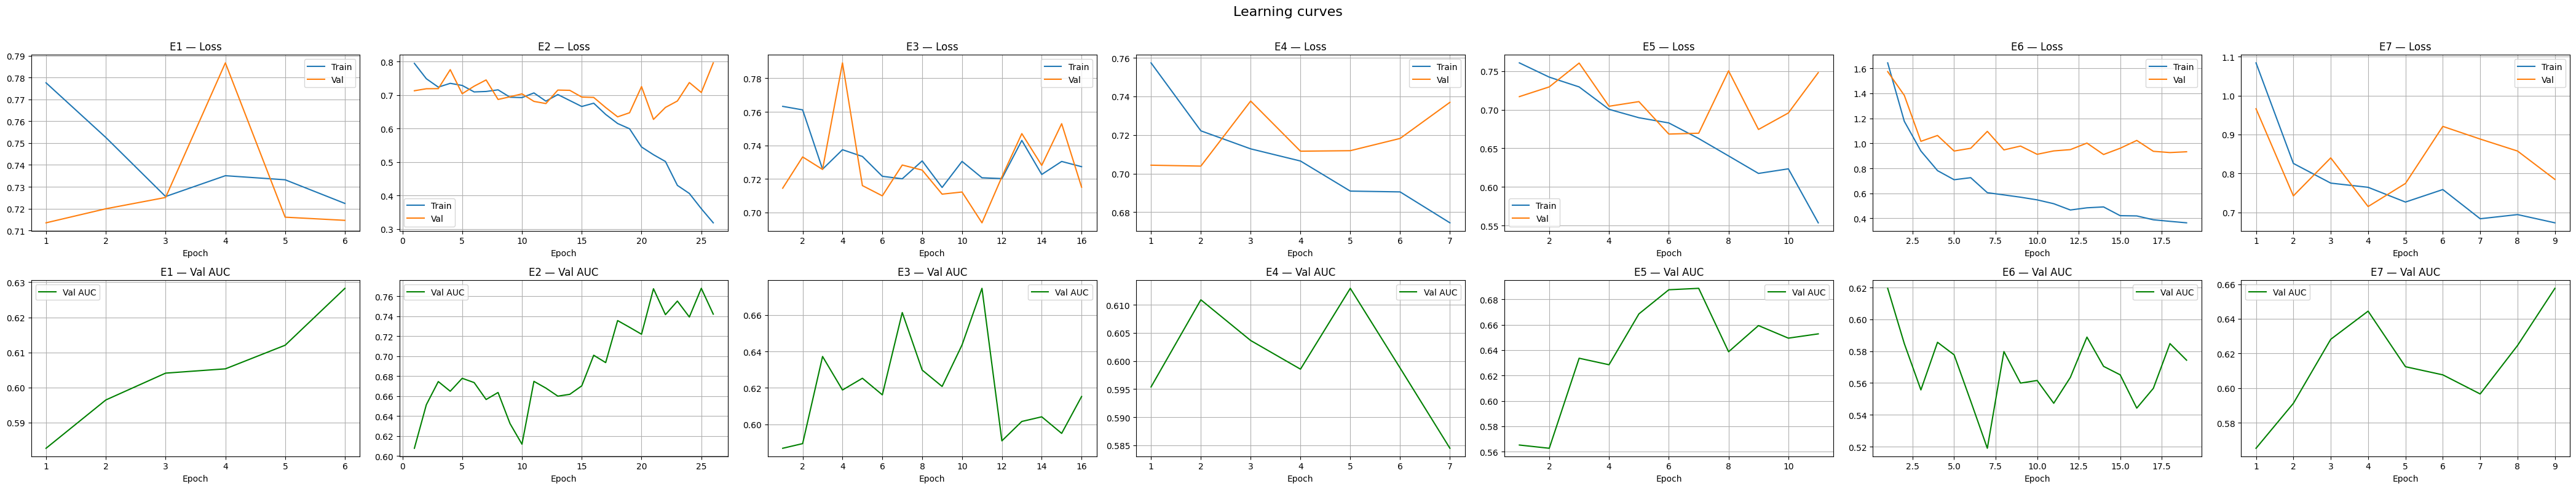

In [11]:
import matplotlib.pyplot as plt

n = len(results)
fig, axes = plt.subplots(2, n, figsize=(6 * n, 8), squeeze=False)
for i, (name, r) in enumerate(sorted(results.items())):
    h = r['history']
    epochs = range(1, len(h['train_loss']) + 1)
    # Loss
    axes[0][i].plot(epochs, h['train_loss'], label='Train')
    axes[0][i].plot(epochs, h['val_loss'], label='Val')
    axes[0][i].set_title(f'{name} — Loss')
    axes[0][i].set_xlabel('Epoch')
    axes[0][i].legend()
    axes[0][i].grid(True)
    # AUC
    axes[1][i].plot(epochs, h['val_auc'], label='Val AUC', color='green')
    axes[1][i].set_title(f'{name} — Val AUC')
    axes[1][i].set_xlabel('Epoch')
    axes[1][i].legend()
    axes[1][i].grid(True)

plt.subplots_adjust(wspace=0.02, hspace=0.15)
plt.suptitle("Learning curves", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()

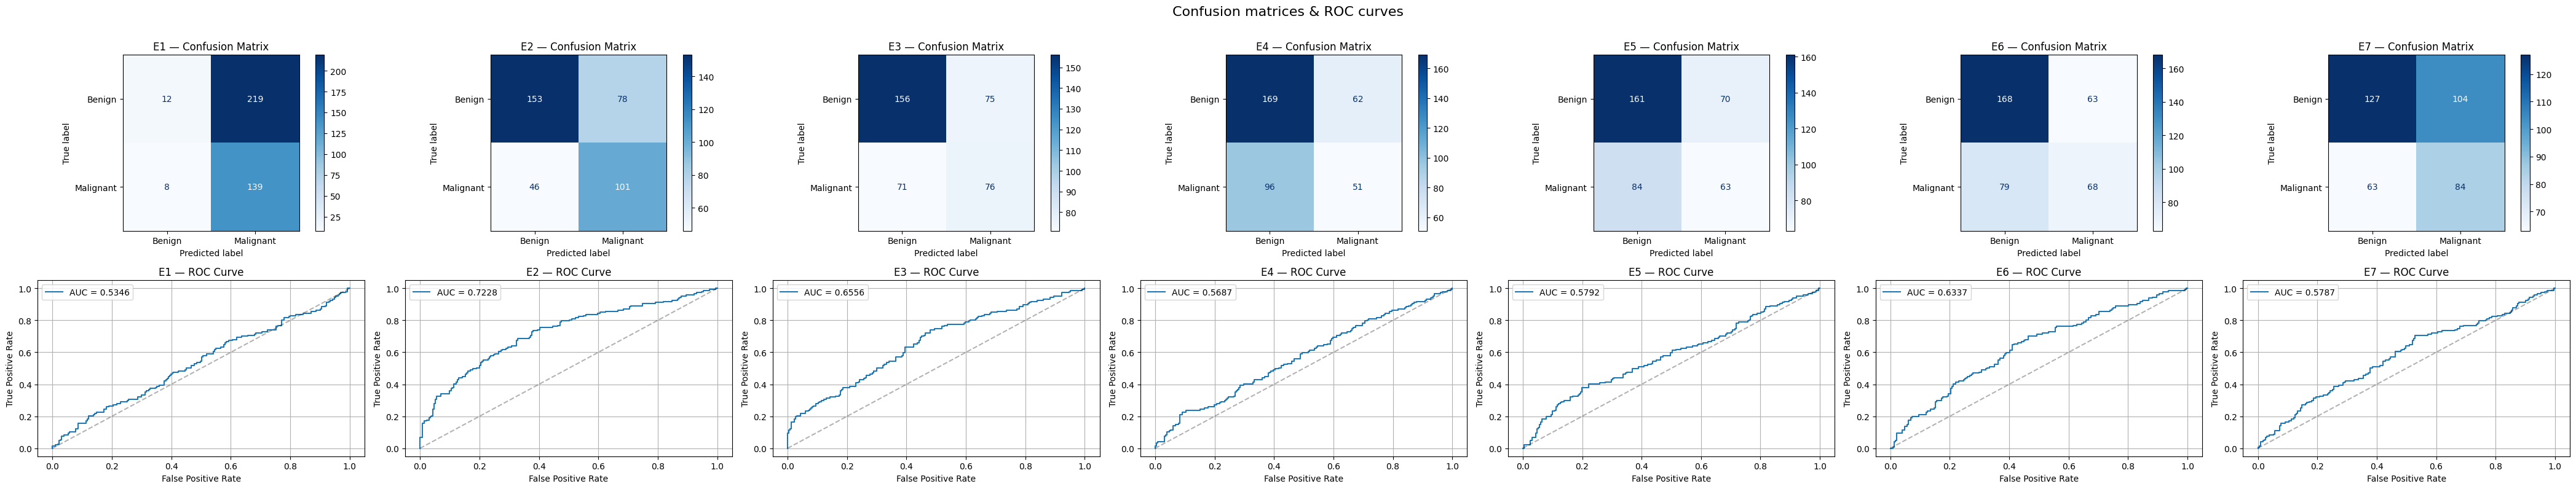

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

n = len(results)
fig, axes = plt.subplots(2, n, figsize=(6 * n, 8), squeeze=False)
for i, (name, r) in enumerate(sorted(results.items())):
    if 'y_true' not in r:
        axes[i][0].set_title(f'{name} — no predictions saved')
        continue
    y_true = np.array(r['y_true'])
    y_prob = np.array(r['y_prob'])
    y_pred = (y_prob > 0.5).astype(int)
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(ax=axes[0][i], cmap='Blues')
    axes[0][i].set_title(f'{name} — Confusion Matrix')
    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1][i].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    axes[1][i].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[1][i].set_title(f'{name} — ROC Curve')
    axes[1][i].set_xlabel('False Positive Rate')
    axes[1][i].set_ylabel('True Positive Rate')
    axes[1][i].legend()
    axes[1][i].grid(True)

plt.subplots_adjust(wspace=0.02, hspace=0.15)
plt.suptitle("Confusion matrices & ROC curves", fontsize=16, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()


To analyze the results, the outcomes of the seven different experiments need to be compared between each other and benchmarked against the papers cited in the thesis.

| Study | ACC | F1 | AUC |
|-------|-----|-----|----|
| Paper 1 (VGG16 + heavy augmentation to 60K images) | 0.844 | 0.85 |0.844 | 
| Paper 2 (EfficientNet-B2, minimal augmentation) | 0.650 | — | 0.679 |
| Paper 3 (BiT + attention + text metadata) |0.796 | 0.780 | 0.878 | 
| E1 | 0.3995 | 0.5505 | 0.5346 |
| E2 | **0.6720** | **0.6196** | **0.7228** |
| E3 | 0.6138 | 0.5101 | 0.6556 |
| E4 | 0.5820 | 0.3923 | 0.5687 |
| E5 | 0.5926 | 0.4500 | 0.5792 |
| E6 | 0.6243 | 0.4892 | 0.6337 |
| E7 | 0.5582 | 0.5015 | 0.5787 |

### Experiments 1 to 3

E2 obtains the best results, whilst E1 is slightly better than randomly choosing between malign or benign (AUC = 0.5). E2, with minial agumentation, obtains better results than the second paper, that also had minimal augmentation but used a EfficientNet-B2 instead of a visual tranasformer. With a bit more detail:
* **E1:** the results are very bad, which can be explained by the fact that ViT-B/16 was pretrained on ImageNet (natural images), not medical images,as well as the raw mammogram images having low contrast. On top of that, the dataset is small (~1K train samples), that can be small for a Visual Transformer, and only basic augmentation was used.
* **E2:** the results are drastically better than E1, even when the only difference is image preprocessing. CLAHE dramatically enhances tissue contrast, making pretrained ViT features useful and it is competitive with Paper 2 (which also used minimal augmentation).
* **E3:** one might think that the gap between E2 and Papers 1 and 3 might be explained by the amount of data augmentation used in those, but E3, that performs more aggressive data augmentation, performs worse than E2. Looking at it with attention, we see that the training loss barely decreased (0.76→0.72 over 16 epochs) vs E2 (0.79→0.32 over 26 epochs); pointing to the aggressive augmentation (rotation, zoom, shear) on already-small crops making training data too hard and causing the model to underfit. With only ~1K samples, aggressive augmentation creates noisier versions of the same data rather than meaningful new examples, whilst the Paper 1 first expanded to 60K images, and then applied augmentation 

#### Conclusion
- **H1 is supported**: preprocessing (CLAHE + denoise) dramatically improves ViT classification (AUC 0.53→0.72)
- Aggressive augmentation without data expansion hurts rather than helps (AUC 0.72→0.66)

### Experiments 4 to 7

TODO